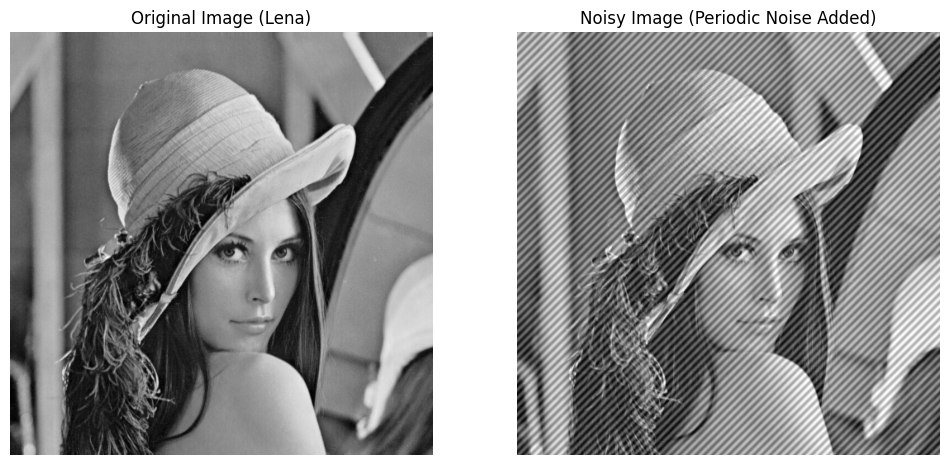

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_orig = cv2.imread('../data/images/lena.png', cv2.IMREAD_GRAYSCALE)

rows, cols = img_orig.shape
x = np.arange(cols)
y = np.arange(rows)
X, Y = np.meshgrid(x, y)

noise = 40 * np.sin(2 * np.pi * 0.1 * X + 2 * np.pi * 0.1 * Y)
img_noisy = np.clip(img_orig + noise, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_orig, cmap='gray')
ax[0].set_title("Original Image (Lena)")
ax[0].axis('off')

ax[1].imshow(img_noisy, cmap='gray')
ax[1].set_title("Noisy Image (Periodic Noise Added)")
ax[1].axis('off')
plt.show()

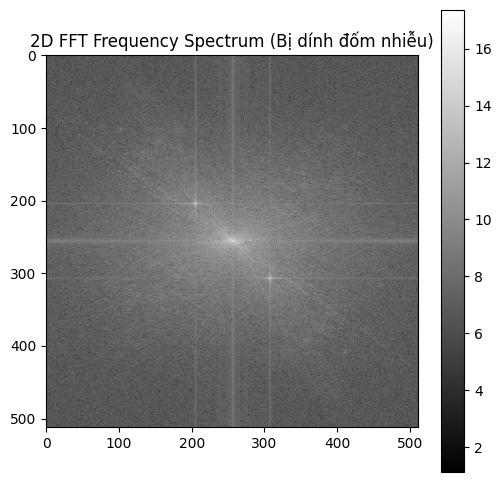

In [2]:
f_transform = np.fft.fft2(img_noisy)
f_transform_shifted = np.fft.fftshift(f_transform)

magnitude_spectrum = np.log(1 + np.abs(f_transform_shifted))

plt.figure(figsize=(6, 6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("2D FFT Frequency Spectrum (Bị dính đốm nhiễu)")
plt.colorbar()
plt.show()

In [7]:
f_transform_clean = f_transform_shifted.copy()

cy, cx = rows // 2, cols // 2

r_mask = 10

offset_y, offset_x = int(rows * 0.1), int(cols * 0.1)

f_transform_clean[cy + offset_y - r_mask : cy + offset_y + r_mask, cx + offset_x - r_mask : cx + offset_x + r_mask] = 0
f_transform_clean[cy - offset_y - r_mask : cy - offset_y + r_mask, cx - offset_x - r_mask : cx - offset_x + r_mask] = 0

f_ishift = np.fft.ifftshift(f_transform_clean)
img_back = np.fft.ifft2(f_ishift)
img_cleaned = np.abs(img_back)
img_cleaned = np.clip(img_cleaned, 0, 255).astype(np.uint8)

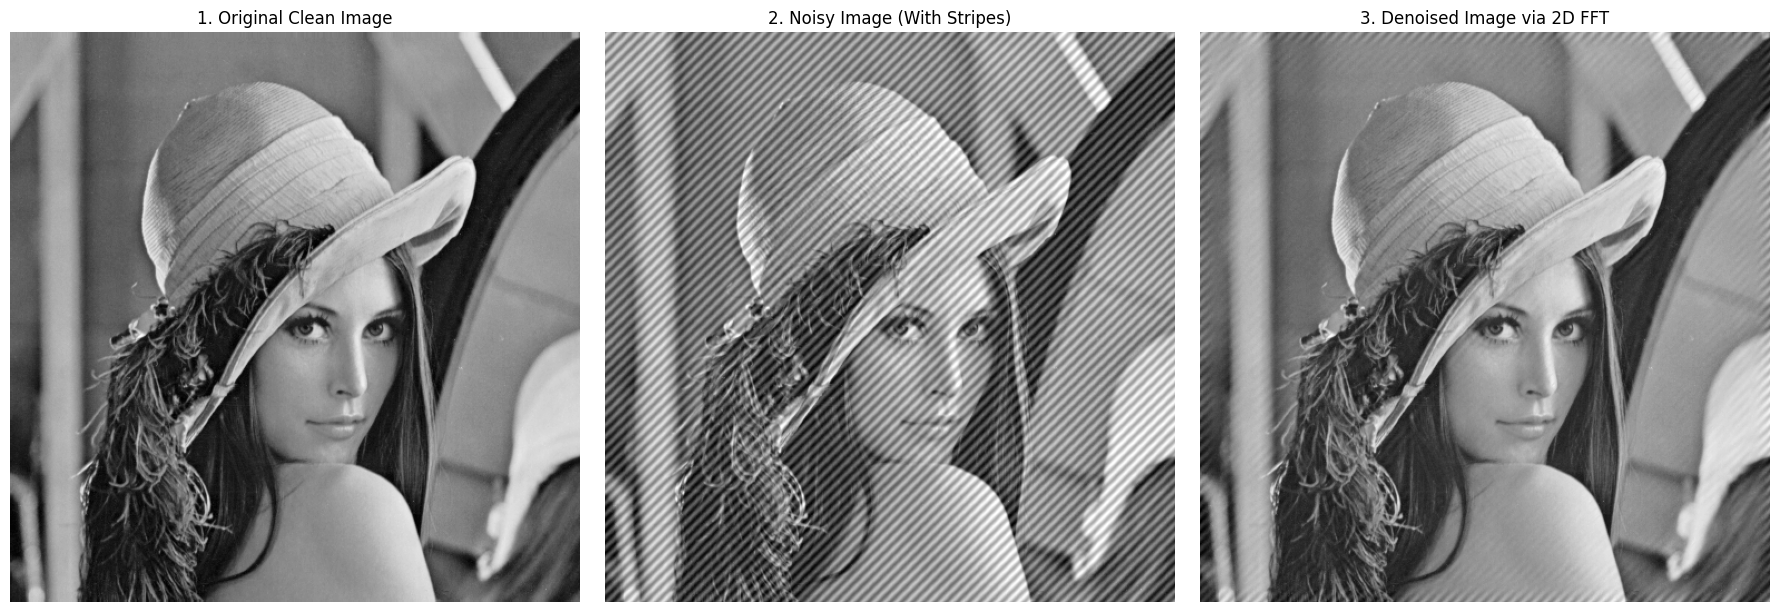

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_orig, cmap='gray')
ax[0].set_title("1. Original Clean Image")
ax[0].axis('off')

ax[1].imshow(img_noisy, cmap='gray')
ax[1].set_title("2. Noisy Image (With Stripes)")
ax[1].axis('off')

ax[2].imshow(img_cleaned, cmap='gray')
ax[2].set_title("3. Denoised Image via 2D FFT")
ax[2].axis('off')

plt.tight_layout()
plt.show()